In [3]:
# Importation des bibliothèques nécessaires 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des données
df = pd.read_csv("../data/raw/credit_risk.csv")

# Aperçu général 
print("=== APERÇU DES DONNÉES === ")
print(df.head())


# Informations sur les colonnes (types, non-null)
print("\n=== INFORMATIONS SUR LES COLONNES === ")
print(df.info())

# Statistiques descriptives
print("\n=== STATISTIQUES DESCRIPTIVES === ")
print(df.describe())

# Vérification des valeurs manquantes
print("\n=== VALEURS MANQUANTES PAR COLONNE === ")
print(df.isnull().sum())

# Distribution des variables cible (loan_status)
print("\n=== DISTRIBUTION DE LA VARIABLE CIBLE (loan_status) === ")
print(df['loan_status'].value_counts())

print("\n=== POURCENTAGE DES CLASSES === ")
print(df['loan_status'].value_counts(normalize=True))

=== APERÇU DES DONNÉES === 
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y   

Nous remarquons que les moyennes et les écart-types sont très différents d'une variable à une autre. Les données ne sont donc probablement pas à la même échelle.

De plus, il y a des valeurs manquantes au niveau des variables person_emp_length (float) et lon_int_rate (float). Ces d"eux variables contiennent probablement des valeurs abberantes vue la différence très importante entre leur 3è quartile et leur maximum.

Ces résultats montre qu'il y a un déséquilibre de classe au niveau des données. En effet, environ 22% des client sont en défaut de paiement contre un peu plus de 78% de bons clients.  
Dans la partie préparation des données pour la modélisation il va falloir resoudre ce problème. 



### 1. Problème détecté : Outliers (Valeurs aberrantes)
- **Âge (`person_age`)** : Je vois des valeurs jusqu'à 140 ans. Je vais supprimer toutes les lignes où `person_age` > 100 (car impossible).
- **Revenu (`person_income`)** : Je vais vérifier s'il y a des revenus à 0. Si c'est le cas, je les supprimerai car un client sans revenu ne peut pas avoir de prêt cohérent.

### 2. Problème détecté : Valeurs manquantes
- D'après `df.isnull().sum()`, les colonnes `person_emp_length` et `loan_int_rate` ont des trous. 
- Comme ce sont des nombres, je les remplacerai par la **médiane** (valeur du milieu) plutôt que par la moyenne, car la médiane est moins sensible aux revenus extrêmes.

### 3. Variables à fort potentiel (Les plus utiles pour le modèle)
- **`loan_percent_income`** : Différence énorme entre les 2 groupes. C'est ma variable N°1.
- **`loan_grade`** : (Je regarde le tableau croisé) Je vois que les notes G et F ont beaucoup plus de défauts. Je garde cette colonne.
- **`loan_int_rate`** : Bon indicateur de risque.

### 4. Déséquilibre de la cible (`loan_status`)
- J'ai environ 22% de clients en défaut (loan_status=1) et 78% de bons payeurs. 
- Le jeu est déséquilibré. Je devrai utiliser le paramètre `class_weight='balanced'` dans mon modèle pour éviter qu'il ne prédise toujours "remboursé".

### 5. Stratégie de nettoyage résumée
1. Nettoyer les outliers (âge > 100).
2. Remplacer les NaN numériques par la médiane.
3. Encoder les colonnes texte (`loan_grade`, `home_ownership`, etc.) en nombres.
4. Normaliser les colonnes numériques pour les mettre à la même échelle


=== CRÉATION DES GRAPHIQUES NUMÉRIQUES === 


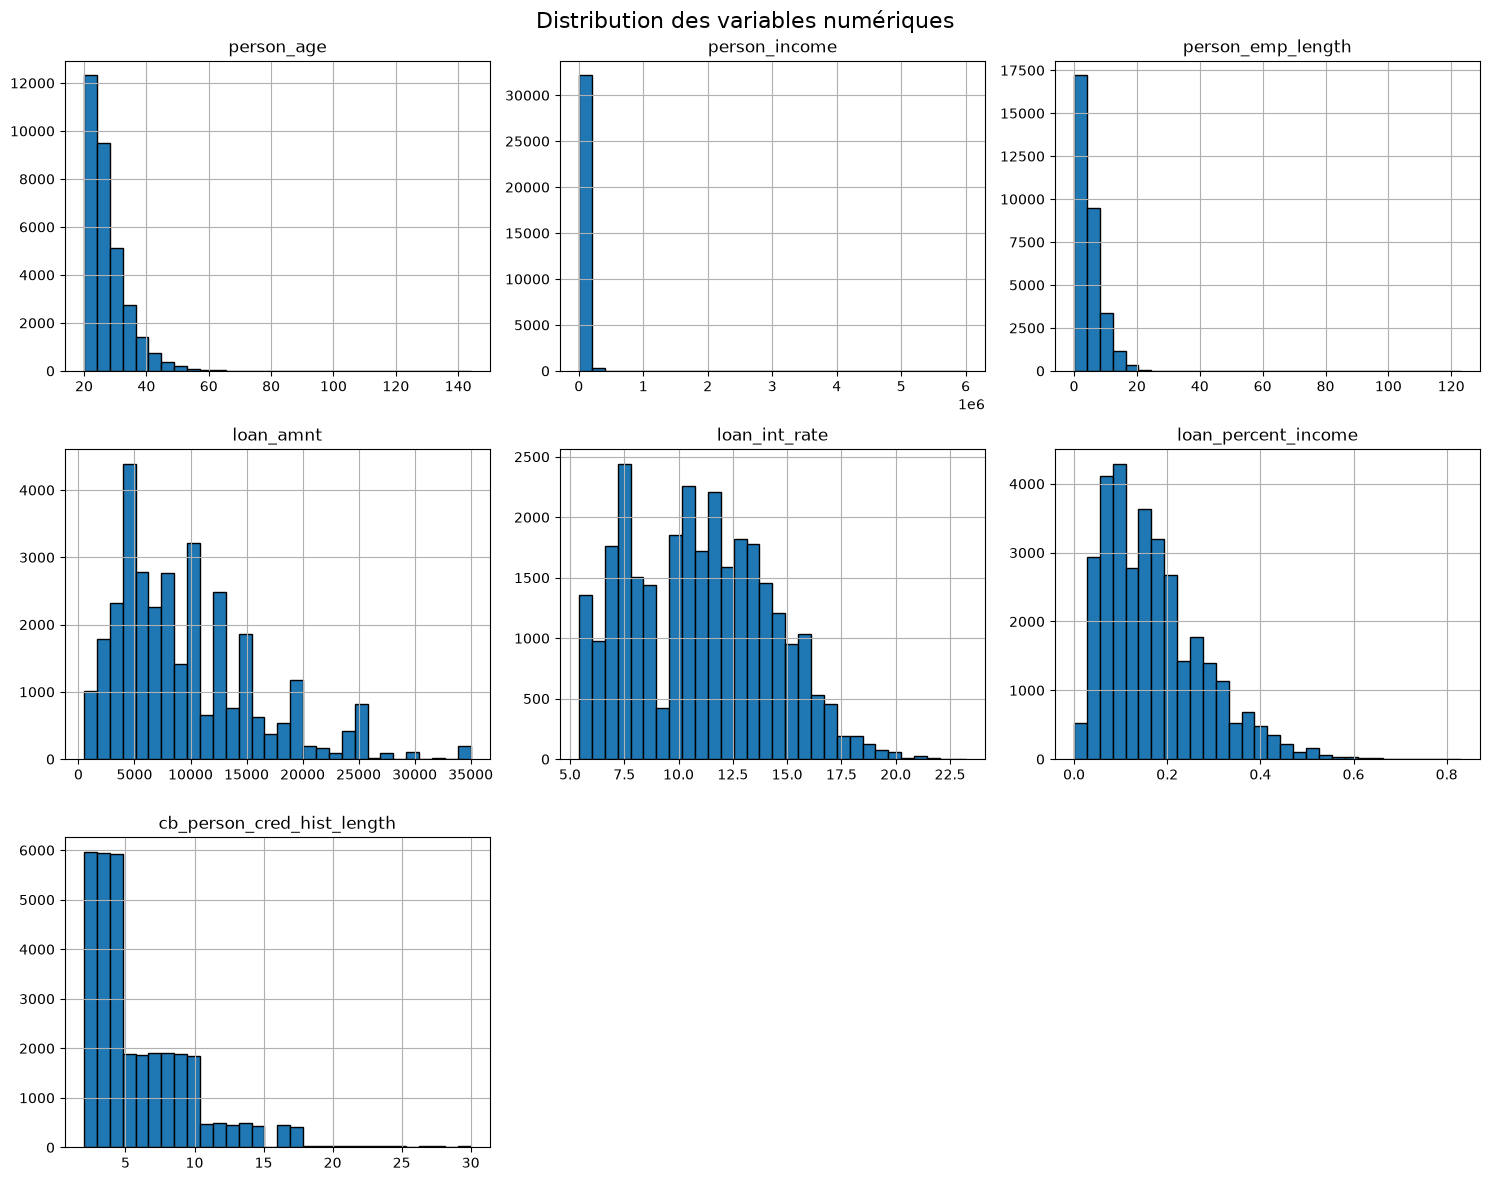

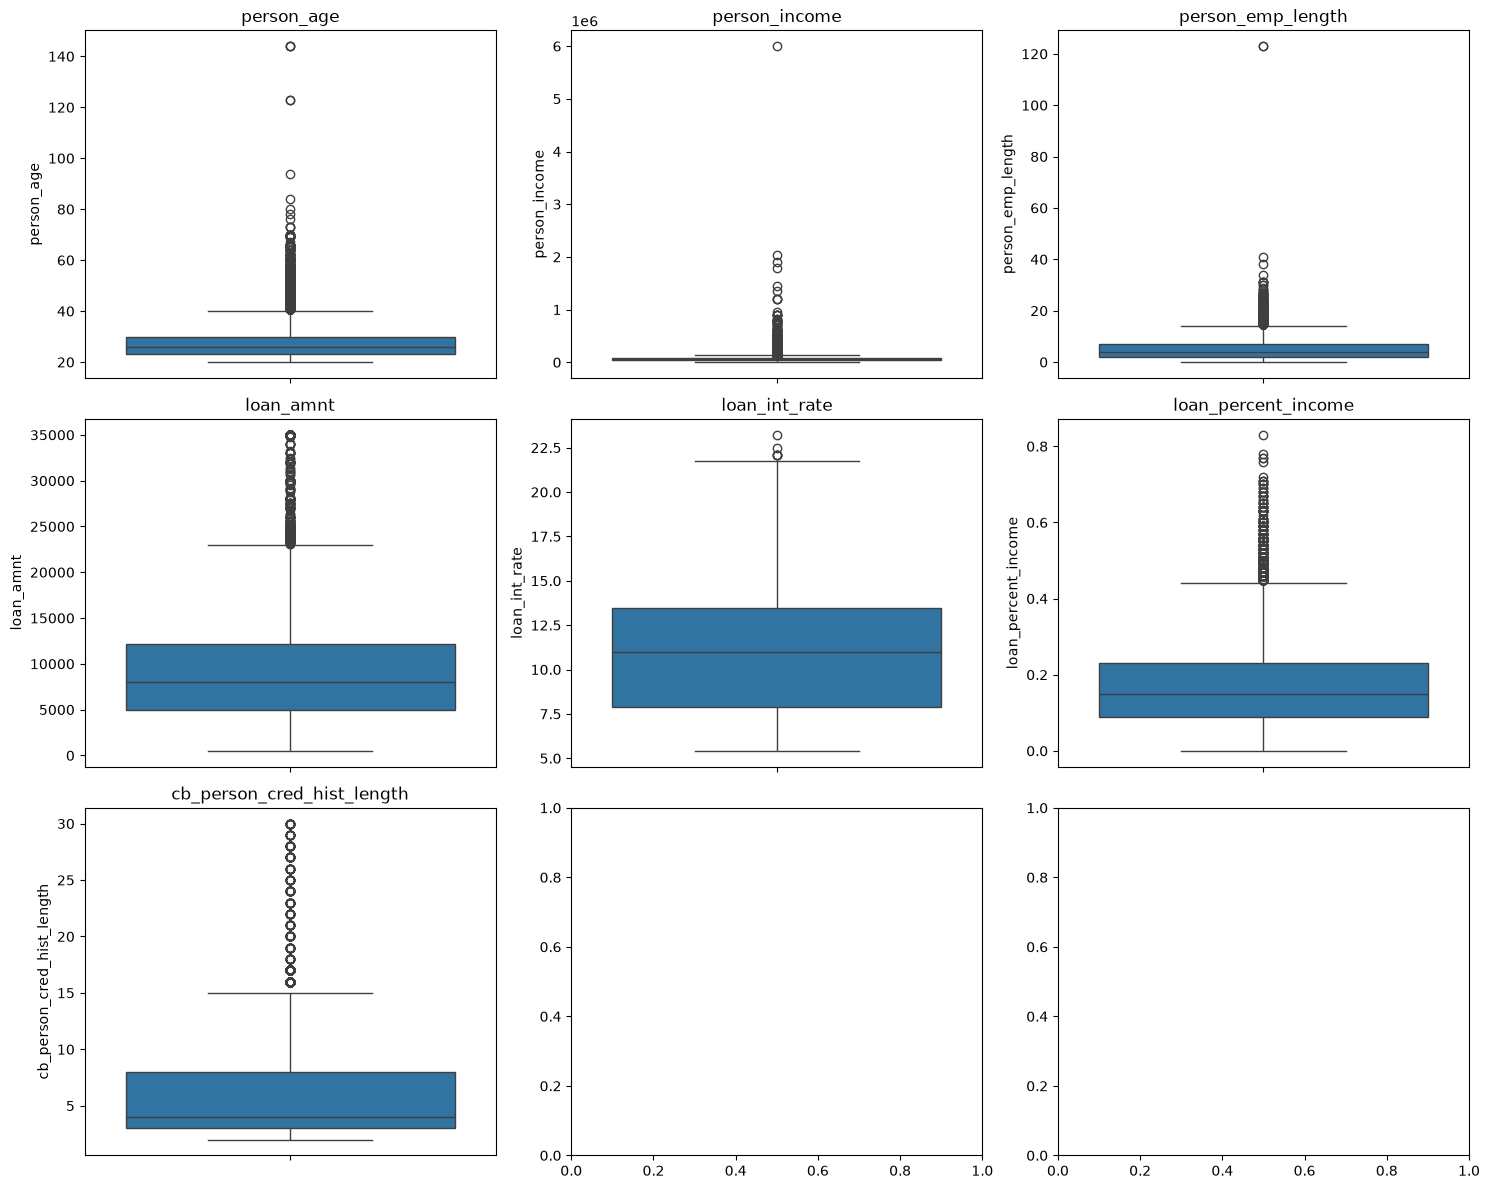


=== ANALYSE DES VARIABLES CATÉGORIELLES === 

=== VALEURS UNIQUES DE PERSON_HOME_OWNERSHIP ===
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64
--------------------------------------------------

=== VALEURS UNIQUES DE LOAN_INTENT ===
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64
--------------------------------------------------

=== VALEURS UNIQUES DE LOAN_GRADE ===
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64
--------------------------------------------------

=== VALEURS UNIQUES DE CB_PERSON_DEFAULT_ON_FILE ===
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64
--------------------------------------------------

=== RELATION DES VARIABLES AVEC LE RISQUE DE DÉFAUT === 


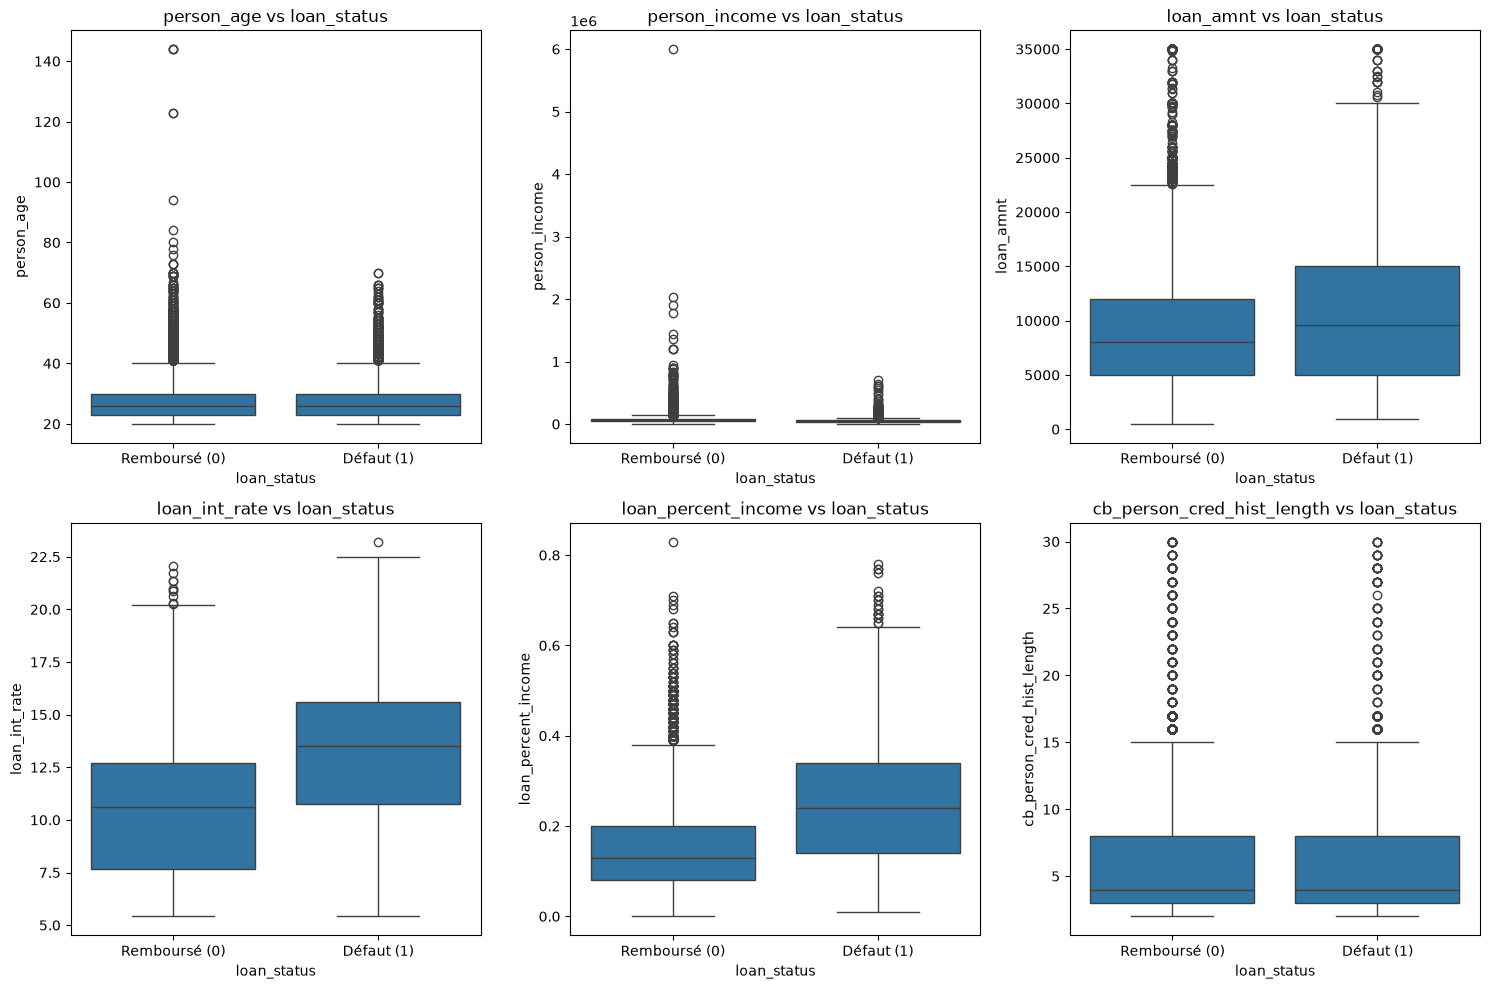


=== PERSON_HOME_OWNERSHIP vs LOAN_STATUS ===
                       % Remboursé   % Défaut
person_home_ownership                        
MORTGAGE                 87.429337  12.570663
OTHER                    69.158879  30.841121
OWN                      92.530960   7.469040
RENT                     68.430013  31.569987
------------------------------------------------------------

=== LOAN_INTENT vs LOAN_STATUS ===
                   % Remboursé   % Défaut
loan_intent                              
DEBTCONSOLIDATION    71.412126  28.587874
EDUCATION            82.783202  17.216798
HOMEIMPROVEMENT      73.897365  26.102635
MEDICAL              73.299292  26.700708
PERSONAL             80.112298  19.887702
VENTURE              85.189718  14.810282
------------------------------------------------------------

=== LOAN_GRADE vs LOAN_STATUS ===
            % Remboursé   % Défaut
loan_grade                        
A             90.043611   9.956389
B             83.724046  16.275954
C        

In [4]:

# Analyse des variables numériques (Histogrammes et Boxplots)

print("\n=== CRÉATION DES GRAPHIQUES NUMÉRIQUES === ")

# select_dtypes(include=[np.number]) : Ne sélectionne que les colonnes qui contiennent des nombres (int ou float).
# .columns.tolist() : Récupère la liste des noms de ces colonnes.
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# On retire la colonne 'loan_status' de la liste car c'est notre cible, on veut analyser les variables explicatives seules.
numerical_cols.remove('loan_status')

# ----  HISTOGRAMMES ----
df[numerical_cols].hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.suptitle("Distribution des variables numériques", size=16)
plt.tight_layout()
plt.show()

# ----  BOXPLOTS (pour les outliers) ----
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
# .flatten() : Transforme la grille 3x3 en une simple liste de 9 éléments, ce qui est plus facile à parcourir avec une boucle.
axes = axes.flatten()

# Boucle for : pour i allant de 0 à 8, on regarde la colonne correspondante dans numerical_cols.
for i, col in enumerate(numerical_cols):
    # sns.boxplot(y=df[col], ax=axes[i]) : Trace un boxplot pour la colonne 'col' et le place dans le graphique 'axes[i]'.
    sns.boxplot(y=df[col], ax=axes[i])
    # axes[i].set_title(col) : Donne le nom de la colonne comme titre au graphique.
    axes[i].set_title(col)

# On ajuste la taille et on affiche.
plt.tight_layout()
plt.show()


#  Analyse des variables catégorielles (valeurs uniques)


print("\n=== ANALYSE DES VARIABLES CATÉGORIELLES === ")

# select_dtypes(include=['object']) : Sélectionne les colonnes contenant du texte (type 'object' dans pandas).
categorical_cols = df.select_dtypes(include=['object','str']).columns.tolist()

# On boucle sur chaque colonne texte.
for col in categorical_cols:
    # On imprime un titre en majuscules.
    print(f"\n=== VALEURS UNIQUES DE {col.upper()} ===")
    # df[col].value_counts() : Compte les occurrences de chaque valeur (ex: combien de 'A', combien de 'B'...).
    print(df[col].value_counts())
    print("-" * 50)  # Imprime une ligne de séparation.


#  Relation avec la cible 
print("\n=== RELATION DES VARIABLES AVEC LE RISQUE DE DÉFAUT === ")

# ---- BOXPLOTS COMPARATIFS (les bons vs les mauvais) ----
# On va comparer la distribution de certaines colonnes chez les gens qui ont remboursé (0) vs ceux qui ont fait défaut (1).

# On choisit manuellement les colonnes qui nous semblent les plus pertinentes.
key_cols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

# On crée une grille de 2 lignes x 3 colonnes.
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    # sns.boxplot(x='loan_status', y=col, data=df) : 
    # - x='loan_status' : L'axe des X sera la cible (0 ou 1).
    # - y=col : L'axe des Y sera la colonne en cours.
    # - data=df : On dit à seaborn d'aller chercher les données dans notre DataFrame.
    sns.boxplot(x='loan_status', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs loan_status')
    # On renomme les étiquettes de l'axe X pour que ce soit plus clair.
    
    axes[i].set_xticks ([0, 1], labels=['Remboursé (0)', 'Défaut (1)'])

plt.tight_layout()
plt.show()

# ---- TABLEAUX CROISÉS (pour les variables textes) ----
# Le tableau croisé permet de voir, en pourcentage, comment se comporte chaque catégorie face au défaut.

for col in categorical_cols:
    print(f"\n=== {col.upper()} vs LOAN_STATUS ===")
    
    # pd.crosstab(df[col], df['loan_status']) : Compte les occurrences.
    # normalize='index' : Transforme les effectifs en pourcentages par ligne.
    # Exemple : pour chaque note de crédit (A, B, C...), on regarde quel % a remboursé et quel % a fait défaut.
    cross_tab = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100
    
    # On renomme les colonnes pour que ce soit plus lisible.
    cross_tab.columns = ['% Remboursé', '% Défaut']
    print(cross_tab)
    print("-" * 60)



In [5]:
# Voir combien de lignes ont un âge supérieur à 100 ans et nettoyer ces valeurs aberrantes.
print(df[df['person_age'] > 100][['person_age']].value_counts())
df = df[df['person_age'] <= 100].copy()


person_age
144           3
123           2
Name: count, dtype: int64


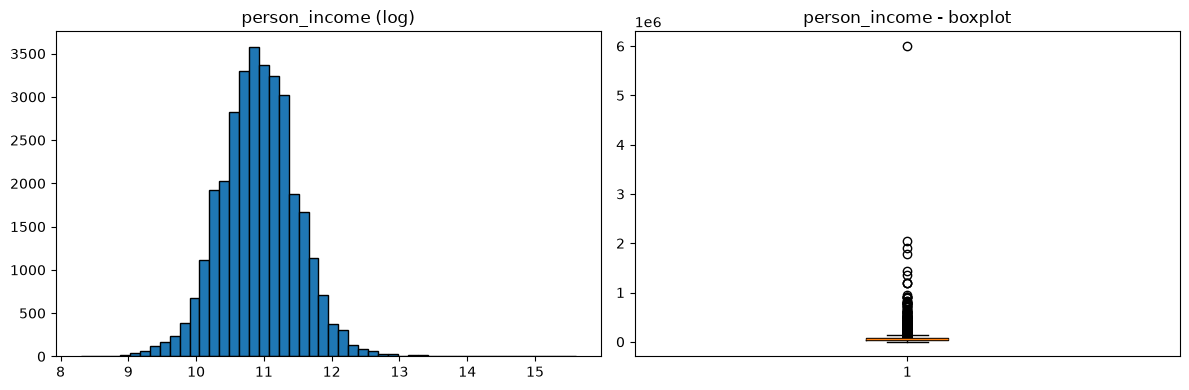

0.950     138000.0
0.990     225200.0
0.995     300000.0
0.999     648000.0
1.000    6000000.0
Name: person_income, dtype: float64


In [ ]:
# Version log de person-income pour visualiser la vraie distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# Version log pour visualiser la vraie distribution
ax[0].hist(np.log1p(df['person_income']), bins=50, edgecolor='black')
ax[0].set_title('person_income (log)')

# Boxplot pour repérer les seuils d'outliers
ax[1].boxplot(df['person_income'])
ax[1].set_title('person_income - boxplot')
plt.tight_layout()
plt.show()

# Quantiles extrêmes pour juger où couper
print(df['person_income'].quantile([0.95, 0.99, 0.995, 0.999, 1.0]))


In [6]:
# Vérification finale
print(df.isnull().sum())
print(df.shape)

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3115
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64
(32576, 12)


In [7]:

from scipy import stats
import numpy as np

def rank_biserial(group0, group1):
    n0, n1 = len(group0), len(group1)
    u_stat, _ = stats.mannwhitneyu(group0, group1)
    # Rank-biserial correlation
    r = 1 - (2 * u_stat) / (n0 * n1)
    return r

numeric_cols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 
                 'loan_percent_income', 'cb_person_cred_hist_length']

print(f"{'Variable':<25} {'p-value':<12} {'Effect size (r)':<15} {'Interprétation'}")
print("-" * 75)

for col in numeric_cols:
    group0 = df[df['loan_status'] == 0][col].dropna()
    group1 = df[df['loan_status'] == 1][col].dropna()
    stat, p_value = stats.mannwhitneyu(group0, group1)
    r = rank_biserial(group0, group1)
    
    abs_r = abs(r)
    if abs_r < 0.1:
        taille = "négligeable"
    elif abs_r < 0.3:
        taille = "petite"
    elif abs_r < 0.5:
        taille = "modérée"
    else:
        taille = "grande"
    
    print(f"{col:<25} {p_value:<12.4f} {r:<15.4f} {taille}")

Variable                  p-value      Effect size (r) Interprétation
---------------------------------------------------------------------------
person_age                0.0000       -0.0463         négligeable
person_income             0.0000       -0.3803         modérée
loan_amnt                 0.0000       0.1174          petite
loan_int_rate             0.0000       0.4465          modérée
loan_percent_income       0.0000       0.4416          modérée
cb_person_cred_hist_length 0.0000       -0.0330         négligeable


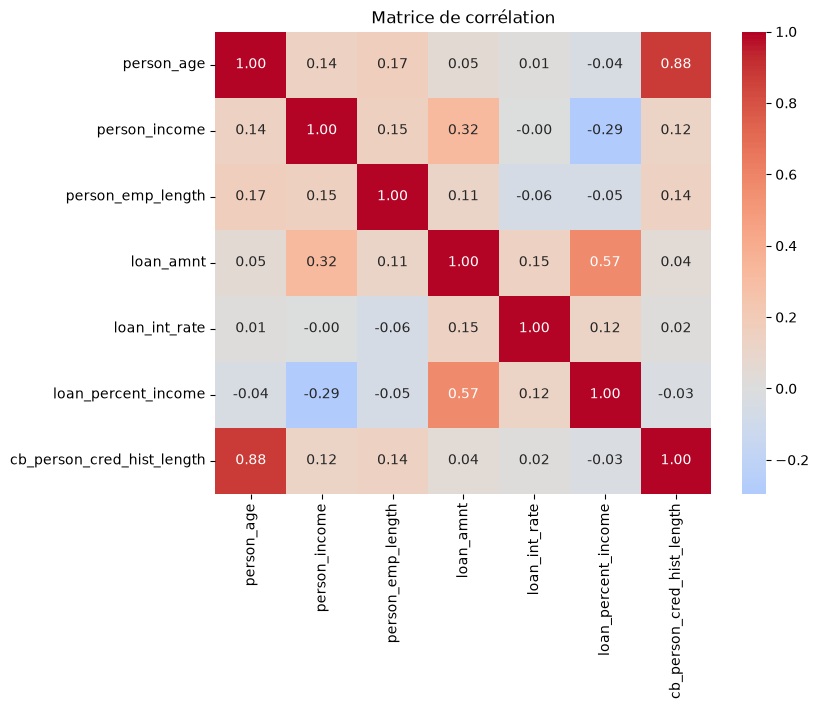

In [8]:
import seaborn as sns

numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 
                 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matrice de corrélation')
plt.show()

               grade_numeric  loan_int_rate
grade_numeric       1.000000       0.933686
loan_int_rate       0.933686       1.000000


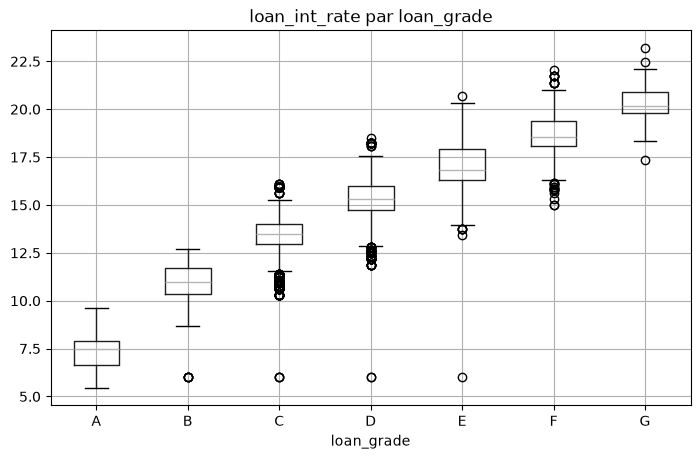

In [9]:
# Encoder le grade en numérique pour vérifier la corrélation avec le taux
grade_order = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7}
df['grade_numeric'] = df['loan_grade'].map(grade_order)

print(df[['grade_numeric', 'loan_int_rate']].corr())

# Visualisation
df.boxplot(column='loan_int_rate', by='loan_grade', figsize=(8,5))
plt.title('loan_int_rate par loan_grade')
plt.suptitle('')
plt.show()

In [10]:
df_cleaned = df.copy() # faire une copie du DataFrame original pour le nettoyage et la préparation des données
# Feature engineering
df_cleaned['person_income_log'] = np.log1p(df_cleaned['person_income'])

# Encodage
df_cleaned['cb_person_default_on_file'] = df_cleaned['cb_person_default_on_file'].map({'Y': 1, 'N': 0})

grade_order = {'A':0, 'B':1, 'C':2, 'D':3, 'E':4, 'F':5, 'G':6}
df_cleaned['loan_grade'] = df_cleaned['loan_grade'].map(grade_order)

df_cleaned = pd.get_dummies(df_cleaned, columns=['person_home_ownership', 'loan_intent'], drop_first=True)

df_cleaned = df_cleaned.drop(columns=['grade_numeric'])

# Vérification finale
print(" === DATAFRAME NETTOYÉ === ")
print( df_cleaned.dtypes)
print(df_cleaned.isnull().sum())
print(df_cleaned.shape)



 === DATAFRAME NETTOYÉ === 
person_age                       int64
person_income                    int64
person_emp_length              float64
loan_grade                       int64
loan_amnt                        int64
loan_int_rate                  float64
loan_status                      int64
loan_percent_income            float64
cb_person_default_on_file        int64
cb_person_cred_hist_length       int64
person_income_log              float64
person_home_ownership_OTHER       bool
person_home_ownership_OWN         bool
person_home_ownership_RENT        bool
loan_intent_EDUCATION             bool
loan_intent_HOMEIMPROVEMENT       bool
loan_intent_MEDICAL               bool
loan_intent_PERSONAL              bool
loan_intent_VENTURE               bool
dtype: object
person_age                        0
person_income                     0
person_emp_length               895
loan_grade                        0
loan_amnt                         0
loan_int_rate                  3115
l

In [11]:
# Imputation loan_int_rate par médiane groupée par grade
df_cleaned['loan_int_rate'] = df_cleaned.groupby('loan_grade')['loan_int_rate'].transform(
    lambda x: x.fillna(x.median())
)

# Imputation person_emp_length par médiane simple 
# (peu de valeurs manquantes ~2.7%, pas besoin de groupement complexe)
df_cleaned['person_emp_length'] = df_cleaned['person_emp_length'].fillna(
    df_cleaned['person_emp_length'].median()
)

# Vérification finale
print(df_cleaned.isnull().sum())

person_age                     0
person_income                  0
person_emp_length              0
loan_grade                     0
loan_amnt                      0
loan_int_rate                  0
loan_status                    0
loan_percent_income            0
cb_person_default_on_file      0
cb_person_cred_hist_length     0
person_income_log              0
person_home_ownership_OTHER    0
person_home_ownership_OWN      0
person_home_ownership_RENT     0
loan_intent_EDUCATION          0
loan_intent_HOMEIMPROVEMENT    0
loan_intent_MEDICAL            0
loan_intent_PERSONAL           0
loan_intent_VENTURE            0
dtype: int64


In [25]:
# Spération des données en train et test
from sklearn.model_selection import train_test_split

X = df_cleaned.drop('loan_status', axis=1)
y = df_cleaned['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shape X_train :", X_train.shape)
print("Shape X_test :", X_test.shape)
print("\nRépartition classes train :")
print(y_train.value_counts(normalize=True))
print("\nRépartition classes test :")
print(y_test.value_counts(normalize=True))

Shape X_train : (26060, 18)
Shape X_test : (6516, 18)

Répartition classes train :
loan_status
0    0.781811
1    0.218189
Name: proportion, dtype: float64

Répartition classes test :
loan_status
0    0.781768
1    0.218232
Name: proportion, dtype: float64


In [26]:
# Standardisation ou mise à l'échelle  des variables numériques continues
from sklearn.preprocessing import StandardScaler  
# Importe StandardScaler, l'outil qui va transformer chaque variable numérique
# pour qu'elle ait une moyenne de 0 et un écart-type de 1

# Liste des colonnes numériques continues à standardiser
# On exclut volontairement les colonnes déjà binaires (0/1) ou dummies (True/False),
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 
                 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
                 'person_income_log', 'loan_grade']  
# loan_grade est incluse car c'est une variable ordinale numérique (0 à 6)

scaler = StandardScaler()  
# Crée une instance du StandardScaler (l'outil de transformation, pas encore appliqué)

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])  
# fit_transform fait DEUX choses en une seule ligne sur X_train UNIQUEMENT :
# 1. "fit" : calcule la moyenne et l'écart-type de CHAQUE colonne à partir de X_train
# 2. "transform" : applique la formule (valeur - moyenne) / écart-type à chaque valeur
# On n'utilise JAMAIS X_test ici, pour éviter une fuite de données 
# (le modèle ne doit apprendre les statistiques que depuis le train)

X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])  
# transform SEUL (pas fit) : applique la même formule que celle apprise sur X_train
# On réutilise la moyenne/écart-type calculés précédemment, 
# on ne recalcule PAS de nouvelles statistiques sur X_test
# C'est la règle d'or : fit sur train, transform sur train ET test

print(X_train[numeric_cols].describe())  
# Vérification : après standardisation, chaque colonne de X_train doit avoir
# une moyenne proche de 0 et un écart-type proche de 1

#print(y_train.value_counts()) #affiche la repartition des données brutes


         person_age  person_income  person_emp_length     loan_amnt  \
count  2.606000e+04   2.606000e+04       2.606000e+04  2.606000e+04   
mean   2.497533e-16  -3.285510e-17       5.016879e-17 -1.908595e-18   
std    1.000019e+00   1.000019e+00       1.000019e+00  1.000019e+00   
min   -1.247554e+00  -1.187366e+00      -1.161852e+00 -1.440912e+00   
25%   -7.600047e-01  -5.235642e-01      -6.730143e-01 -7.259817e-01   
50%   -2.724552e-01  -2.080243e-01      -1.841769e-01 -2.493615e-01   
75%    3.776107e-01   2.548200e-01       5.490792e-01  3.901038e-01   
max    1.077867e+01   3.790532e+01       2.890165e+01  4.040220e+00   

       loan_int_rate  loan_percent_income  cb_person_cred_hist_length  \
count   2.606000e+04         2.606000e+04                2.606000e+04   
mean   -5.466762e-16         5.684887e-17                8.834069e-17   
std     1.000019e+00         1.000019e+00                1.000019e+00   
min    -1.741967e+00        -1.594553e+00               -9.375003e-0

In [27]:
from sklearn.linear_model import LogisticRegression 
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

In [28]:
# Entaînement du modèle 
from sklearn.linear_model import LogisticRegression  


# Création du modèle de régression logistique avec des paramètres spécifiques pour gérer le déséquilibre des classes et assurer la convergence.
model_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)  
# Crée le modèle avec les paramètres suivants :
# - class_weight='balanced' : compense le déséquilibre 78/22 automatiquement,
#   en donnant plus de poids aux erreurs commises sur la classe minoritaire (Défaut)
# - random_state=42 : pour la reproductibilité (même résultat à chaque exécution)
# - max_iter=1000 : nombre maximum d'itérations pour que l'algorithme converge

#Entraîne le modèle : l'algorithme apprend les coefficients optimaux
model_lr.fit(X_train, y_train)  
# Entraîne le modèle : l'algorithme apprend les coefficients optimaux 
print("Modèle entraîné avec succès")  


Modèle entraîné avec succès


=== RAPPORT DE CLASSIFICATION ===
               precision    recall  f1-score   support

Remboursé (0)       0.93      0.79      0.85      5094
   Défaut (1)       0.51      0.80      0.62      1422

     accuracy                           0.79      6516
    macro avg       0.72      0.79      0.74      6516
 weighted avg       0.84      0.79      0.80      6516


=== MATRICE DE CONFUSION ===


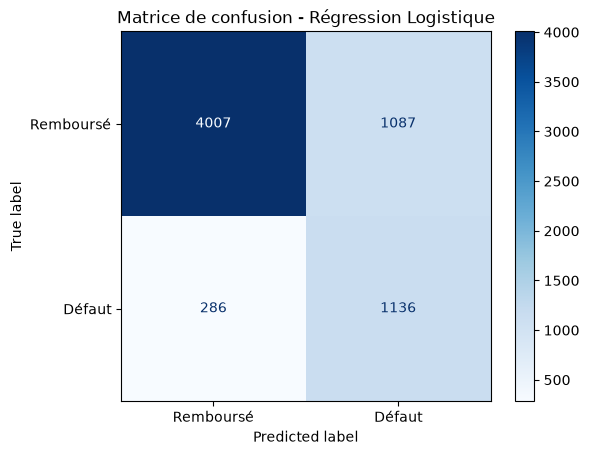


=== AUC-ROC : 0.8684 ===


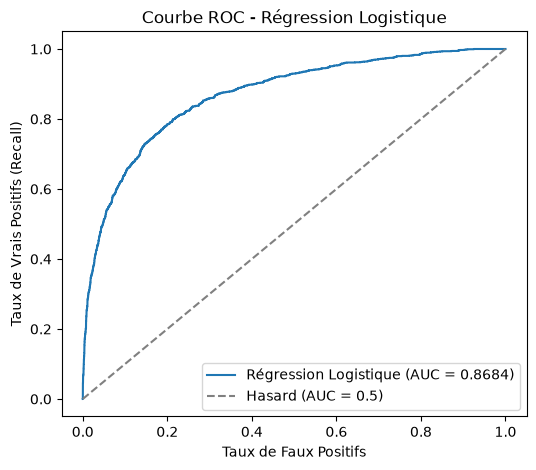

In [ ]:

from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)  

# - classification_report : calcule precision, recall, f1-score pour chaque classe
# - ConfusionMatrixDisplay : affiche la matrice de confusion sous forme graphique
import matplotlib.pyplot as plt  


# --- Prédictions ---
y_pred = model_lr.predict(X_test)  
# Demande au modèle de prédire la classe (0 ou 1) pour chaque ligne de X_test
# Le modèle utilise un seuil de décision de 0.5 par défaut :
# si probabilité de défaut >= 0.5 → prédit 1, sinon → prédit 0

y_pred_proba = model_lr.predict_proba(X_test)[:, 1]  
# Demande au modèle les PROBABILITÉS (pas juste 0/1) pour chaque ligne
# predict_proba retourne 2 colonnes : [proba classe 0, proba classe 1]
# [:, 1] sélectionne uniquement la colonne des probabilités de la classe 1 (Défaut)
# Nécessaire pour calculer l'AUC et tracer la courbe ROC

# --- Rapport de classification ---
print("=== RAPPORT DE CLASSIFICATION ===")
print(classification_report(y_test, y_pred, target_names=['Remboursé (0)', 'Défaut (1)']))  
# Compare y_test (réalité) et y_pred (prédictions du modèle)
# Affiche pour CHAQUE classe :
# - precision : parmi les prédits "Défaut", combien le sont vraiment ?
# - recall : parmi les vrais "Défaut", combien le modèle en a détecté ?
# - f1-score : moyenne harmonique entre precision et recall (équilibre les deux)
# - support : nombre d'exemples réels de chaque classe dans le test

# --- Matrice de confusion ---
print("\n=== MATRICE DE CONFUSION ===")
cm = confusion_matrix(y_test, y_pred)  

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Remboursé', 'Défaut'])  
disp.plot(cmap='Blues', values_format='d')  
# Affiche la matrice avec une palette de couleurs bleues
# values_format='d' force l'affichage en nombres entiers (pas de notation scientifique)
plt.title('Matrice de confusion - Régression Logistique')
plt.show()

# --- AUC-ROC ---
auc_score = roc_auc_score(y_test, y_pred_proba)  
# Calcule l'AUC (Area Under Curve) : mesure globale de la capacité du modèle

print(f"\n=== AUC-ROC : {auc_score:.4f} ===")
# --- Courbe ROC ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)  
# Calcule les coordonnées de la courbe ROC :
# fpr (False Positive Rate) = taux de fausses alertes, en abscisse
# tpr (True Positive Rate) = taux de vraies détections (= recall), en ordonnée
# thresholds = les différents seuils de décision testés (pas utilisé ici pour le tracé)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Régression Logistique (AUC = {auc_score:.4f})')  
# Trace la courbe ROC du modèle
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Hasard (AUC = 0.5)')  
# Trace une ligne diagonale de référence : c'est la performance d'un modèle aléatoire
# Plus la courbe du modèle s'éloigne de cette diagonale (vers le coin haut-gauche), mieux c'est
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC - Régression Logistique')
plt.legend()
plt.show()

scale_pos_weight calculé : 3.5832
Modèle XGBoost entraîné avec succès

=== RAPPORT DE CLASSIFICATION - XGBoost ===
               precision    recall  f1-score   support

Remboursé (0)       0.94      0.95      0.95      5094
   Défaut (1)       0.81      0.80      0.81      1422

     accuracy                           0.92      6516
    macro avg       0.88      0.87      0.88      6516
 weighted avg       0.92      0.92      0.92      6516


=== MATRICE DE CONFUSION - XGBoost ===


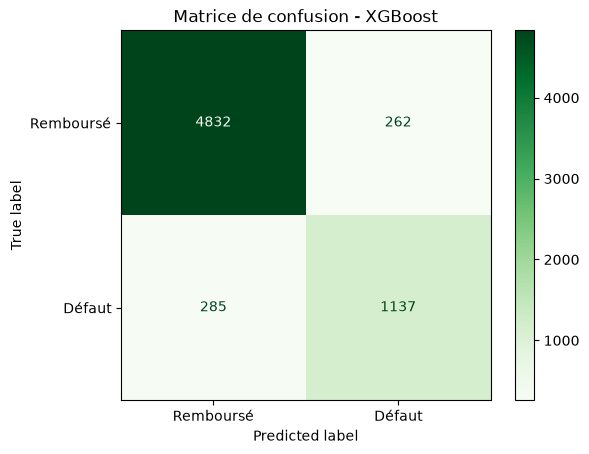


=== AUC-ROC XGBoost : 0.9509 ===


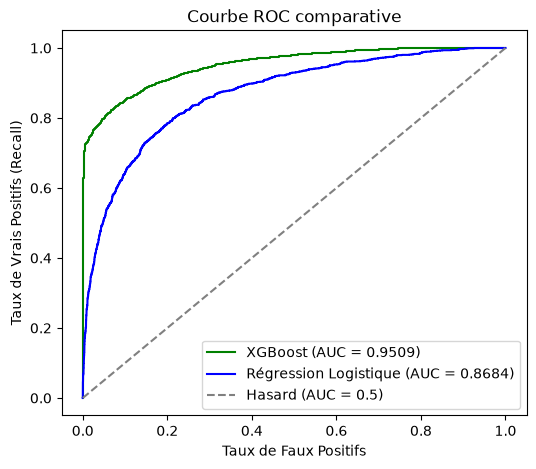

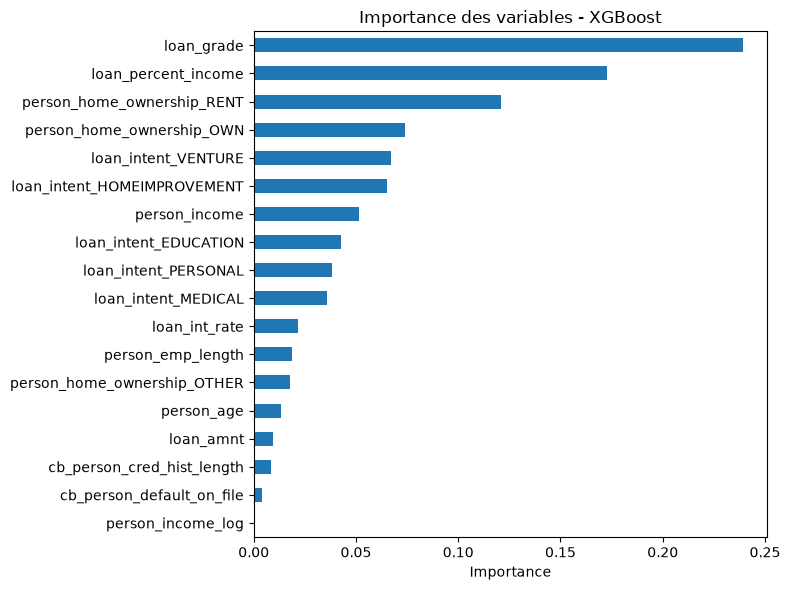

In [30]:
import xgboost as xgb
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
# Mêmes outils d'évaluation que pour la régression logistique, pour pouvoir comparer les deux

import matplotlib.pyplot as plt

# --- Gestion du déséquilibre pour XGBoost ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
# XGBoost n'a pas de 'class_weight' comme la régression logistique
# Il utilise plutôt scale_pos_weight : un ratio qui indique de combien 
# sur-pondérer la classe minoritaire (1 = Défaut)
# Calcul : nombre de "Remboursé" / nombre de "Défaut" 
# (ici environ 20374 / 5686 ≈ 3.58)
print(f"scale_pos_weight calculé : {scale_pos_weight:.4f}")

# --- Entraînement du modèle ---
model_xgb = xgb.XGBClassifier(
    n_estimators=200,
    # Nombre d'arbres construits successivement (chaque arbre corrige les erreurs du précédent)
    max_depth=5,
    # Profondeur maximale de chaque arbre (contrôle la complexité, évite le sur-apprentissage 
    # si trop élevé)
    learning_rate=0.1,
    # Vitesse d'apprentissage : à quel point chaque nouvel arbre corrige fort les erreurs 
    # précédentes (plus petit = apprentissage plus lent mais souvent plus stable)
    scale_pos_weight=scale_pos_weight,
    # Applique le rééquilibrage des classes calculé ci-dessus
    random_state=42,
    # Pour la reproductibilité
    eval_metric='logloss'
    # Métrique utilisée en interne par XGBoost pour évaluer ses propres progrès pendant 
    # l'entraînement (n'affecte pas directement nos métriques d'évaluation finales ci-dessous)
)
# Crée le modèle XGBoost avec ses hyperparamètres
# NOTE : contrairement à la régression logistique, XGBoost n'a pas besoin de X_train standardisé
# (les arbres de décision sont insensibles à l'échelle des variables), 
# mais on peut réutiliser le même X_train/X_test sans problème, ça n'altère pas les résultats

model_xgb.fit(X_train, y_train)
# Entraîne le modèle sur les données d'entraînement
print("Modèle XGBoost entraîné avec succès")

# --- Prédictions ---
y_pred_xgb = model_xgb.predict(X_test)
# Prédictions de classe (0 ou 1) avec le seuil par défaut de 0.5

y_pred_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]
# Probabilités de la classe 1 (Défaut), nécessaires pour l'AUC et la courbe ROC

# --- Rapport de classification ---
print("\n=== RAPPORT DE CLASSIFICATION - XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Remboursé (0)', 'Défaut (1)']))
# Affiche precision, recall, f1-score pour chaque classe, comme pour la régression logistique

# --- Matrice de confusion ---
print("\n=== MATRICE DE CONFUSION - XGBoost ===")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Remboursé', 'Défaut'])
disp_xgb.plot(cmap='Greens', values_format='d')
# cmap='Greens' pour différencier visuellement du graphique bleu de la régression logistique
plt.title('Matrice de confusion - XGBoost')
plt.show()

# --- AUC-ROC ---
auc_score_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"\n=== AUC-ROC XGBoost : {auc_score_xgb:.4f} ===")

# --- Courbe ROC comparative (XGBoost vs Régression Logistique) ---
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
# Recalcule les points de la courbe ROC pour XGBoost

plt.figure(figsize=(6,5))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_score_xgb:.4f})', color='green')
# Courbe XGBoost
plt.plot(fpr, tpr, label=f'Régression Logistique (AUC = {auc_score:.4f})', color='blue')
# Réutilise fpr/tpr/auc_score déjà calculés dans le bloc précédent (régression logistique)
# pour superposer les deux courbes sur le même graphique et comparer directement
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Hasard (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC comparative')
plt.legend()
plt.show()

# --- Feature importance ---
importances = pd.Series(model_xgb.feature_importances_, index=X_train.columns)
# Récupère l'importance de chaque variable telle que calculée par XGBoost
importances = importances.sort_values(ascending=False)
# Trie de la plus importante à la moins importante

plt.figure(figsize=(8,6))
importances.plot(kind='barh')
# Graphique en barres horizontales
plt.gca().invert_yaxis()
# Inverse l'axe pour avoir la variable la plus importante en haut
plt.title('Importance des variables - XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [31]:
import joblib
# Sauvegarde du modèle XGBoost entraîné dans un fichier .pkl
joblib.dump(model_xgb, '../models/xgb_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']

In [24]:
import json

feature_columns = X_train.columns.tolist()
# Récupère la liste exacte et l'ordre exact des colonnes utilisées à l'entraînement

with open('../models/feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)
# Sauvegarde cette liste, l'API l'utilisera pour "aligner" les nouvelles données
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 
                 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
                 'person_income_log', 'loan_grade']
with open('../models/numeric_cols.json', 'w') as f:
    json.dump(numeric_cols, f)

TEST DE ROBUSTESTE 

In [ ]:
# --- Version XGBoost SANS loan_grade (test du risque de fuite de données) ---

# On retire loan_grade des features, on garde tout le reste y compris loan_int_rate
X_train_no_grade = X_train.drop(columns=['loan_grade'])
X_test_no_grade = X_test.drop(columns=['loan_grade'])
# Crée des copies des jeux de features sans la colonne loan_grade,
# pour comparer avec le modèle initial qui l'incluait

model_xgb_no_grade = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
# Mêmes hyperparamètres que le modèle initial, pour une comparaison équitable

model_xgb_no_grade.fit(X_train_no_grade, y_train)
# Entraîne ce nouveau modèle sans loan_grade

y_pred_no_grade = model_xgb_no_grade.predict(X_test_no_grade)
y_pred_proba_no_grade = model_xgb_no_grade.predict_proba(X_test_no_grade)[:, 1]
# Prédictions de classe et de probabilité, comme précédemment

print("=== RAPPORT DE CLASSIFICATION - XGBoost SANS loan_grade ===")
print(classification_report(y_test, y_pred_no_grade, target_names=['Remboursé (0)', 'Défaut (1)']))

auc_no_grade = roc_auc_score(y_test, y_pred_proba_no_grade)
print(f"\n=== AUC-ROC XGBoost SANS loan_grade : {auc_no_grade:.4f} ===")
print(f"=== AUC-ROC XGBoost AVEC loan_grade : {auc_score_xgb:.4f} ===")
print(f"=== Écart : {auc_score_xgb - auc_no_grade:.4f} ===")
# Compare directement les deux AUC pour quantifier l'apport réel de loan_grade